<a href="https://colab.research.google.com/github/YABIGAIL23/Simulaci-n-II/blob/main/Clase_03_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estimar por simulación de Montecarlo el coeficiente de correlación entre $W_{10}$ Y $W_{20}$

In [3]:
from os import timerfd_settime
import numpy as np
from scipy.stats import pearsonr

#Parametros
np.random.seed(42)
n_sim = 200_000

#Incrementos
incrementos_0_10 = np.random.normal(0, 1, size=(n_sim, 10))
incrementos_10_20 = np.random.normal(0, 1, size=(n_sim, 10))

#W10 y W20
W10 = incrementos_0_10.sum(axis=1)
W20 = W10 + incrementos_10_20.sum(axis=1)

#Correlación de Pearson
rho_hat, p_value = pearsonr(W10, W20)

#Comparación con el valor teórico
rho_teorico = 10 / np.sqrt(10 * 20)

print(f"Correlación estimada (Montecarlo): {rho_hat:.5f}")
print(f"p-value:                            {p_value:.5e}")
print(f"Correlación teórica (1/sqrt(2)):    {rho_teorico:.5f}")
print(f"Error absoluto:                      {abs(rho_hat - rho_teorico):.5f}")

Correlación estimada (Montecarlo): 0.70839
p-value:                            0.00000e+00
Correlación teórica (1/sqrt(2)):    0.70711
Error absoluto:                      0.00128
Tiempo que tarda en correr el proceso <built-in function timerfd_settime>


Dibujar 4 trayectorias para $W_0, W_1,..., W_{100}$

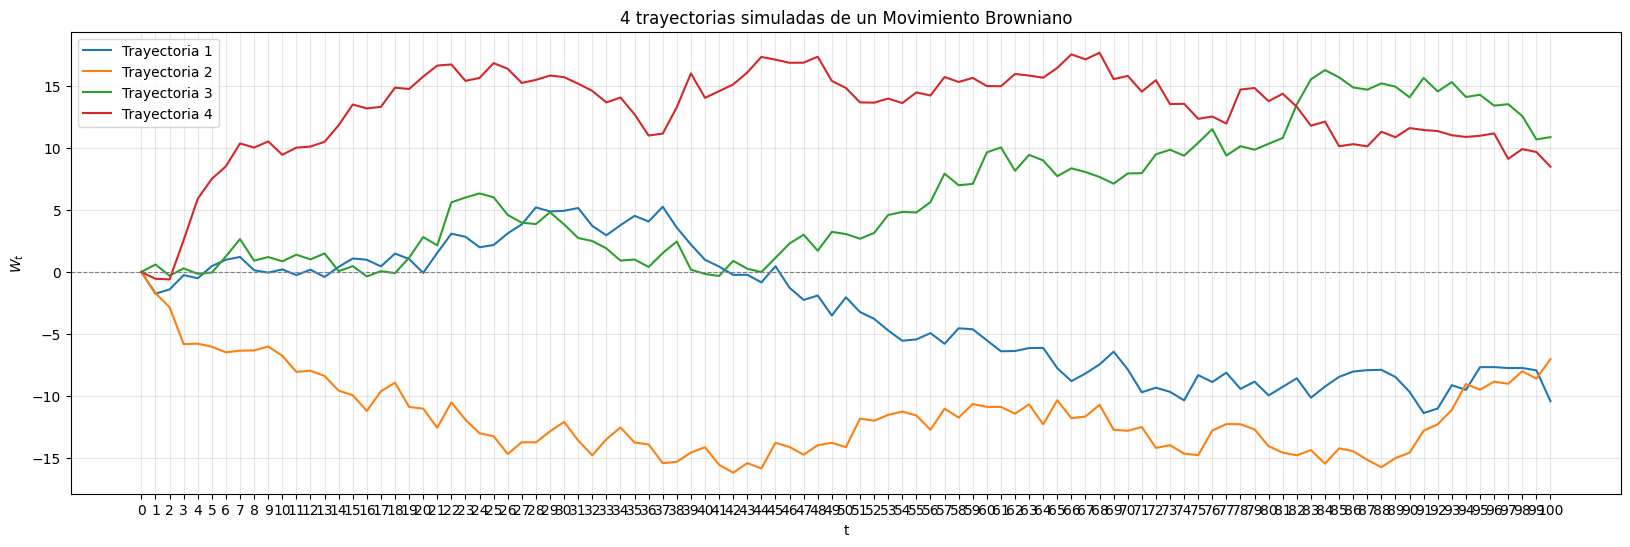

In [20]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(100)

n_trayectorias = 4
n_pasos = 100  #de t=0 a t=100
tiempos = np.arange(0, n_pasos + 1)

#Incrementos independientes N(0,1) para cada trayectoria
incrementos = np.random.normal(0, 1, size=(n_trayectorias, n_pasos))

#W0 = 0, y luego suma acumulada de incrementos
W0 = np.zeros((n_trayectorias, 1))
trayectorias = np.concatenate([W0, np.cumsum(incrementos, axis=1)], axis=1)

#Gráfica
plt.figure(figsize=(20, 6))
for i in range(n_trayectorias):
    plt.plot(tiempos, trayectorias[i], marker='o', label=f'Trayectoria {i+1}')

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('4 trayectorias simuladas de un Movimiento Browniano')
plt.xlabel('t')
plt.ylabel('$W_t$')
plt.xticks(tiempos)
plt.legend()
plt.grid(alpha=0.3)
plt.show()